In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import ast
import random
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
df = pd.read_csv("news_multilabel.csv")
df["labels"] = df["labels"].apply(ast.literal_eval)

allowed = ['ganjar_group', 'prabowo_gibran_group', 'anies_cak_imin_group']
df = df[df['labels'].apply(lambda x: x[0] in allowed)]

label2id = {l:i for i,l in enumerate(allowed)}
df['label_id'] = df['labels'].apply(lambda x: label2id[x[0]])

In [3]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label_id'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=42
)

In [4]:
def augment_text(text):
    words = text.split()
    random.shuffle(words)
    return " ".join(words)

counts = Counter(train_df['label_id'])
max_count = int(max(counts.values()) * 0.8)

augmented = []

for label, count in counts.items():
    subset = train_df[train_df['label_id'] == label]
    needed = max_count - count

    if needed > 0:
        samples = subset.sample(n=min(len(subset), needed), replace=True)
        for _, row in samples.iterrows():
            augmented.append({
                "article_text": augment_text(row['article_text']),
                "label_id": row['label_id']
            })

train_df = pd.concat([train_df, pd.DataFrame(augmented)], ignore_index=True)



In [5]:
MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(train_df['article_text'])

def encode(df):
    seqs = tokenizer.texts_to_sequences(df['article_text'])
    return pad_sequences(seqs, maxlen=MAX_LEN)

X_train = encode(train_df)
X_val   = encode(val_df)
X_test  = encode(test_df)

y_train = train_df['label_id'].values
y_val   = val_df['label_id'].values
y_test  = test_df['label_id'].values



In [6]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val, y_val), batch_size=64)
test_loader  = DataLoader(TextDataset(X_test, y_test), batch_size=64)


In [7]:
class LSTMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(MAX_WORDS, 300)
        self.lstm = nn.LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(128, 3)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = torch.mean(out, dim=1)
        return self.fc(self.dropout(out))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier().to(device)



In [8]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)



In [9]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.counter = 0
        self.best = None
        self.stop = False

    def __call__(self, val_loss):
        if self.best is None or val_loss < self.best:
            self.best = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early = EarlyStopping()

train_losses, val_losses, val_f1_scores = [], [], []


In [10]:
for epoch in range(20):
    model.train()
    total_loss = 0

    for X, y in tqdm(train_loader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0
    preds, trues = [], []

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            val_loss += criterion(outputs, y).item()

            p = torch.argmax(outputs, dim=1).cpu().numpy()
            preds.extend(p)
            trues.extend(y.cpu().numpy())

    val_loss /= len(val_loader)
    val_f1 = f1_score(trues, preds, average='macro')

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f} | F1 {val_f1:.4f}")

    early(val_loss)
    if early.stop:
        print("Early stopping")
        break



100%|██████████| 139/139 [00:01<00:00, 77.64it/s] 


Epoch 1 | Train 0.7952 | Val 0.4364 | F1 0.8403


100%|██████████| 139/139 [00:01<00:00, 103.35it/s]


Epoch 2 | Train 0.3777 | Val 0.3596 | F1 0.8796


100%|██████████| 139/139 [00:01<00:00, 102.43it/s]


...

Epoch 5 | Train 0.2411 | Val 0.3504 | F1 0.8919


100%|██████████| 139/139 [00:01<00:00, 103.05it/s]


Epoch 6 | Train 0.2202 | Val 0.3450 | F1 0.8840


100%|██████████| 139/139 [00:01<00:00, 99.95it/s] 

Epoch 7 | Train 0.1858 | Val 0.3625 | F1 0.8880
Early stopping


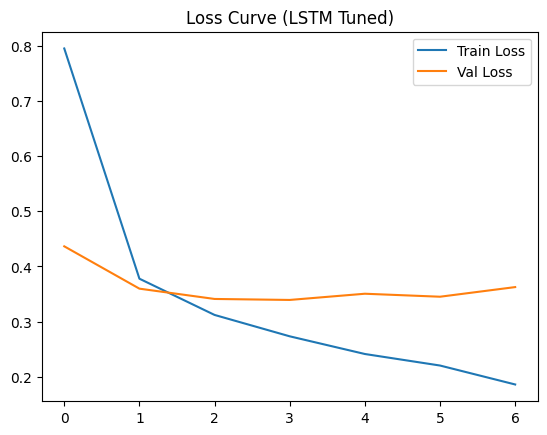

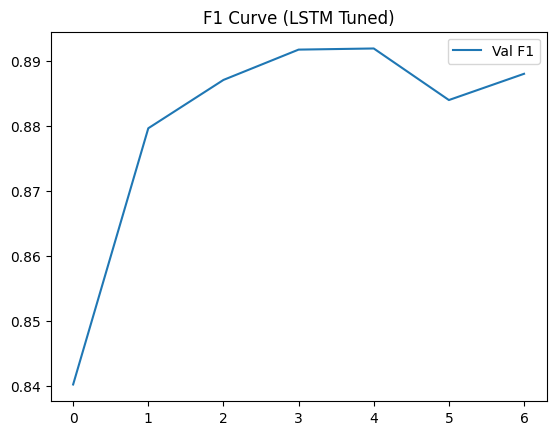

In [11]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve (LSTM Tuned)")
plt.show()

plt.figure()
plt.plot(val_f1_scores, label='Val F1')
plt.legend()
plt.title("F1 Curve (LSTM Tuned)")
plt.show()


In [12]:
model.eval()
preds, trues = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)
        p = torch.argmax(outputs, dim=1).cpu().numpy()

        preds.extend(p)
        trues.extend(y.numpy())

print("\nF1 Macro:", f1_score(trues, preds, average='macro'))
print(classification_report(trues, preds, target_names=allowed))




F1 Macro: 0.874500494837326
                      precision    recall  f1-score   support

        ganjar_group       0.90      0.87      0.89       403
prabowo_gibran_group       0.87      0.87      0.87       387
anies_cak_imin_group       0.83      0.90      0.87       211

            accuracy                           0.88      1001
           macro avg       0.87      0.88      0.87      1001
        weighted avg       0.88      0.88      0.88      1001



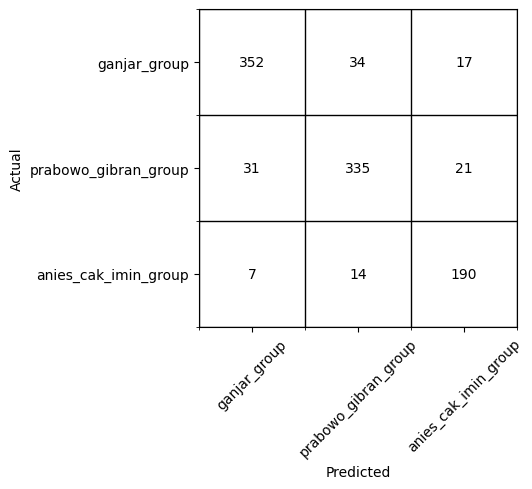

In [13]:
cm = confusion_matrix(trues, preds)

fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(np.ones_like(cm), cmap='gray', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(allowed)))
ax.set_yticks(np.arange(len(allowed)))
ax.set_xticklabels(allowed, rotation=45)
ax.set_yticklabels(allowed)

ax.set_xticks(np.arange(-.5, len(allowed), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(allowed), 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()